In [3]:
# dedup_pipeline.py
import pandas as pd, re, itertools
from unidecode import unidecode
from rapidfuzz import fuzz
import networkx as nx


def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unidecode(s)
    s = re.sub(r"[\.,;:/#&\-\(\)]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s


def normalize_address(s):
    s = normalize_text(s)
    s = re.sub(r"\b(st)\b", "street", s)
    s = re.sub(r"\b(rd)\b", "road", s)
    s = re.sub(r"\b(av|ave)\b", "avenue", s)
    return s


def sim_name(r1, r2):
    name1 = (r1["given_name_n"] + " " + r1["surname_n"]).strip()
    name2 = (r2["given_name_n"] + " " + r2["surname_n"]).strip()
    if not name1 or not name2:
        return 0.0
    return fuzz.token_sort_ratio(name1, name2) / 100.0


def sim_address(r1, r2):
    a1 = r1["address_1_n"]
    a2 = r2["address_1_n"]
    if not a1 or not a2:
        return 0.0
    return fuzz.token_set_ratio(a1, a2) / 100.0


def sim_dob(r1, r2):
    return (
        1.0
        if r1["date_of_birth_n"] == r2["date_of_birth_n"]
        and pd.notna(r1["date_of_birth_n"])
        else 0.0
    )


def sim_ssn(r1, r2):
    s1 = str(r1.get("soc_sec_id", "") or "").strip()
    s2 = str(r2.get("soc_sec_id", "") or "").strip()
    if not s1 or not s2:
        return 0.0
    return 1.0 if s1 == s2 else 0.5 if s1[-4:] == s2[-4:] else 0.0


def overall_similarity(r1, r2):
    return (
        0.4 * sim_name(r1, r2)
        + 0.3 * sim_address(r1, r2)
        + 0.2 * sim_dob(r1, r2)
        + 0.1 * sim_ssn(r1, r2)
    )


def run_pipeline(infile="input/dedup_data.csv", threshold=0.85):
    df = pd.read_csv(infile)
    for col in ["given_name", "surname", "address_1", "address_2", "suburb", "state"]:
        df[col + "_n"] = df[col].apply(normalize_text)
    df["address_1_n"] = df["address_1"].apply(normalize_address)
    df["date_of_birth_n"] = pd.to_datetime(
        df["date_of_birth"], errors="coerce"
    ).dt.strftime("%Y-%m-%d")
    df["postcode_n"] = df["postcode"].astype(str).str.zfill(4).fillna("")

    df["block_key"] = (
        df["postcode_n"].fillna("") + "_" + df["surname_n"].str[:2].fillna("")
    )
    blocks = df.groupby("block_key")

    edges = []
    for _, block in blocks:
        if len(block) <= 1:
            continue
        rows = list(block.to_dict("records"))
        for r1, r2 in itertools.combinations(rows, 2):
            sim = overall_similarity(r1, r2)
            if sim >= threshold:
                edges.append((r1["id"], r2["id"]))

    G = nx.Graph()
    G.add_nodes_from(df["id"].tolist())
    G.add_edges_from(edges)
    comps = list(nx.connected_components(G))
    cid_map = {}
    for idx, comp in enumerate(comps):
        for rid in comp:
            cid_map[rid] = idx
    df["cluster_id"] = df["id"].map(cid_map).fillna(-1).astype(int)
    df.to_csv("output/dedup_clusters.csv", index=False)
    print("Done. Clusters saved to dedup_clusters.csv")
    return df

In [4]:
run_pipeline()

Done. Clusters saved to dedup_clusters.csv


,given_name,surname,street_number,address_1,address_2,suburb,postcode,state,date_of_birth,soc_sec_id,...,given_name_n,surname_n,address_1_n,address_2_n,suburb_n,state_n,date_of_birth_n,postcode_n,block_key,cluster_id
0,mitchell,green,7.0,wallaby place,delmar,cleveland,2119,sa,19560409.0,1804974,...,mitchell,green,wallaby place,delmar,cleveland,sa,1970-01-01,2119,2119_gr,0
1,harley,mccarthy,177.0,pridhamstreet,milton,marsden,3165,nsw,19080419.0,6089216,...,harley,mccarthy,pridhamstreet,milton,marsden,nsw,1970-01-01,3165,3165_mc,1
2,madeline,mason,54.0,hoseason street,lakefront retrmnt vlge,granville,4881,nsw,19081128.0,2185997,...,madeline,mason,hoseason street,lakefront retrmnt vlge,granville,nsw,1970-01-01,4881,4881_ma,2
3,isabelle,NaN,23.0,gundulu place,currin ga,utakarra,2193,wa,19921119.0,4314184,...,isabelle,,gundulu place,currin ga,utakarra,wa,1970-01-01,2193,2193_,3
4,taylor,hathaway,7.0,yuranigh court,brentwood vlge,NaN,4220,nsw,19991207.0,9144092,...,taylor,hathaway,yuranigh court,brentwood vlge,,nsw,1970-01-01,4220,4220_ha,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,jack,campbell,169.0,marr street,rhosewyn,oakleigh,3356,vic,19770109.0,1485686,...,jack,campbell,marr street,rhosewyn,oakleigh,vic,1970-01-01,3356,3356_ca,1755
4996,william,lazaroff,12.0,leah ylose,milwlood,forbes,7256,qld,NaN,8072193,...,william,lazaroff,leah ylose,milwlood,forbes,qld,NaN,7256,7256_la,3317
4997,destynii,bowerman,12.0,halford crescent,sutton,nollamara,2431,qld,19880821.0,6089424,...,destynii,bowerman,halford crescent,sutton,nollamara,qld,1970-01-01,2431,2431_bo,1137
4998,gianni,dooley,38.0,ashburton circuit,brentwood vlge,ryde,6025,qld,19371212.0,5854405,...,gianni,dooley,ashburton circuit,brentwood vlge,ryde,qld,1970-01-01,6025,6025_do,1486


In [6]:
df = pd.read_csv("output/dedup_clusters.csv")
df["cluster_id"].value_counts()

cluster_id
44      6
413     6
1375    6
122     6
615     6
       ..
1470    1
1471    1
1473    1
1477    1
3317    1
Name: count, Length: 3318, dtype: int64

In [ ]:
duplicates = df[df["cluster_id"] != -1].sort_values("cluster_id")
for cid, group in duplicates.groupby("cluster_id"):
    print(f"Cluster {cid}:")
    print(group[["id", "given_name", "surname", "address_1", "date_of_birth"]])
    print()

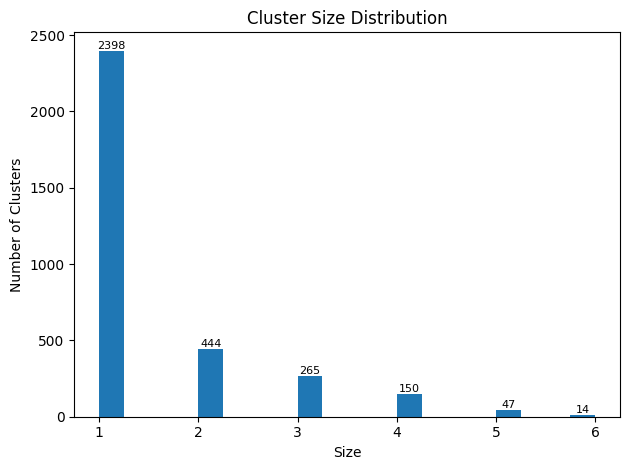

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output/dedup_clusters.csv")

# Count cluster sizes
cluster_sizes = df["cluster_id"].value_counts().sort_index()

plt.figure()
n, bins, patches = plt.hist(cluster_sizes, bins=20)

plt.title("Cluster Size Distribution")
plt.xlabel("Size")
plt.ylabel("Number of Clusters")

# 🔹 Add labels on each bar
for count, x in zip(n, patches):
    height = count
    if height > 0:  # show only non-zero bars
        plt.text(
            x.get_x() + x.get_width() / 2,
            height,
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

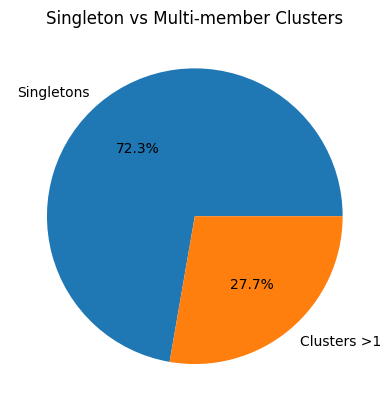

In [14]:
singleton_count = (cluster_sizes == 1).sum()
multi_count = (cluster_sizes > 1).sum()

plt.figure()
plt.pie(
    [singleton_count, multi_count],
    labels=["Singletons", "Clusters >1"],
    autopct="%1.1f%%",
)
plt.title("Singleton vs Multi-member Clusters")
plt.show()

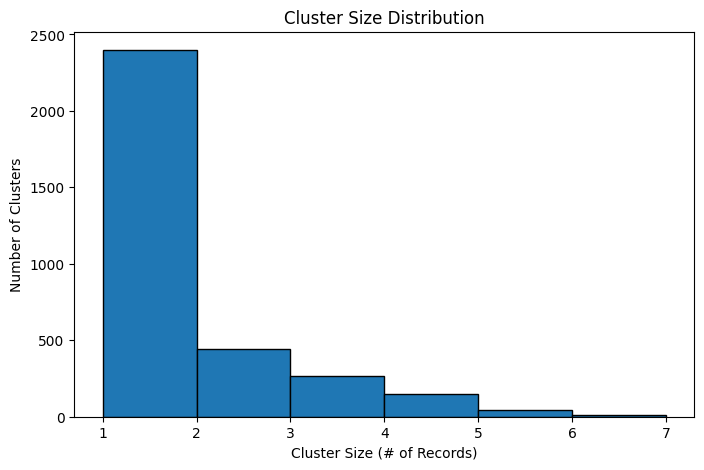

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output/dedup_clusters.csv")

cluster_counts = df["cluster_id"].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(cluster_counts, bins=range(1, cluster_counts.max() + 2), edgecolor="black")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster Size (# of Records)")
plt.ylabel("Number of Clusters")
plt.show()

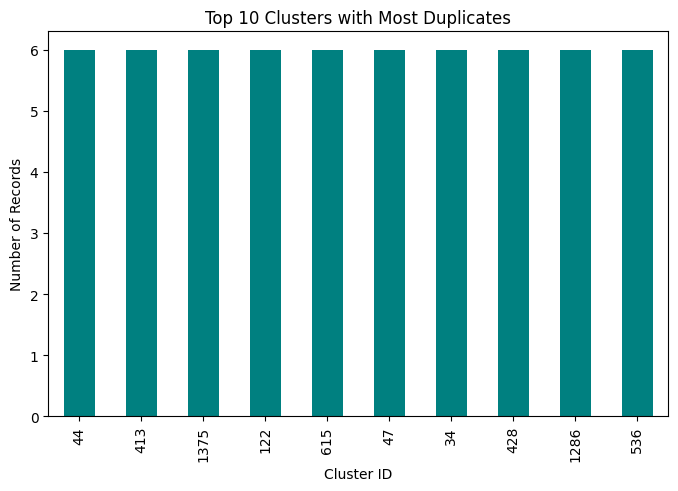

In [23]:
top_clusters = cluster_counts[cluster_counts > 1].head(10)

plt.figure(figsize=(8, 5))
top_clusters.plot(kind="bar", color="teal")
plt.title("Top 10 Clusters with Most Duplicates")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Records")
plt.show()

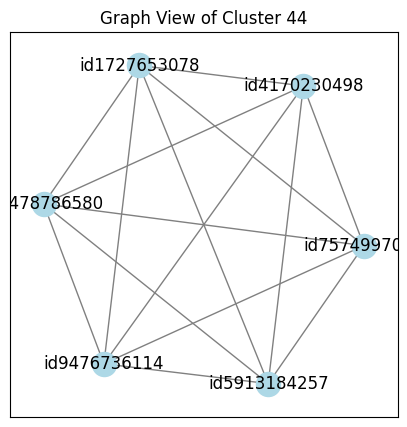

In [24]:
import networkx as nx

# Pick one cluster with duplicates
cid = cluster_counts[cluster_counts > 1].index[0]
cluster_records = df[df["cluster_id"] == cid]

# Build a mini graph
G = nx.Graph()
G.add_nodes_from(cluster_records["id"].tolist())

# Add edges between records in same cluster
for i in range(len(cluster_records)):
    for j in range(i + 1, len(cluster_records)):
        G.add_edge(cluster_records.iloc[i]["id"], cluster_records.iloc[j]["id"])

plt.figure(figsize=(5, 5))
nx.draw_networkx(G, with_labels=True, node_color="lightblue", edge_color="gray")
plt.title(f"Graph View of Cluster {cid}")
plt.show()